In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

In [24]:
df= pd.read_csv(r'D:\DataScienceAndAICourse\April\10th - SVM\SVM\pulsar_stars.csv')

In [26]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [28]:
col_names = df.columns
col_names

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [30]:
df.columns = df.columns.str.strip()

In [32]:
col_names = df.columns
col_names

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [34]:
df.columns = ['IP Mean', 'IP Sd', 'IP Kurtosis', 'IP Skewness', 
              'DM-SNR Mean', 'DM-SNR Sd', 'DM-SNR Kurtosis', 'DM-SNR Skewness', 'target_class']

In [36]:
df.head()

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [38]:
df['target_class'].value_counts()

target_class
0    16259
1     1639
Name: count, dtype: int64

In [44]:
import numpy as np
df['target_class'].value_counts()/len(df)

target_class
0    0.908426
1    0.091574
Name: count, dtype: float64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IP Mean          17898 non-null  float64
 1   IP Sd            17898 non-null  float64
 2   IP Kurtosis      17898 non-null  float64
 3   IP Skewness      17898 non-null  float64
 4   DM-SNR Mean      17898 non-null  float64
 5   DM-SNR Sd        17898 non-null  float64
 6   DM-SNR Kurtosis  17898 non-null  float64
 7   DM-SNR Skewness  17898 non-null  float64
 8   target_class     17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [49]:
df.isnull().sum()

IP Mean            0
IP Sd              0
IP Kurtosis        0
IP Skewness        0
DM-SNR Mean        0
DM-SNR Sd          0
DM-SNR Kurtosis    0
DM-SNR Skewness    0
target_class       0
dtype: int64

In [52]:
round(df.describe(),2)

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness,target_class
count,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00
mean,111.08,46.55,0.48,1.77,12.61,26.33,8.30,104.86,0.09
std,25.65,6.84,1.06,6.17,29.47,19.47,4.51,106.51,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.96,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,83.06,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.43,10.70,139.31,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00


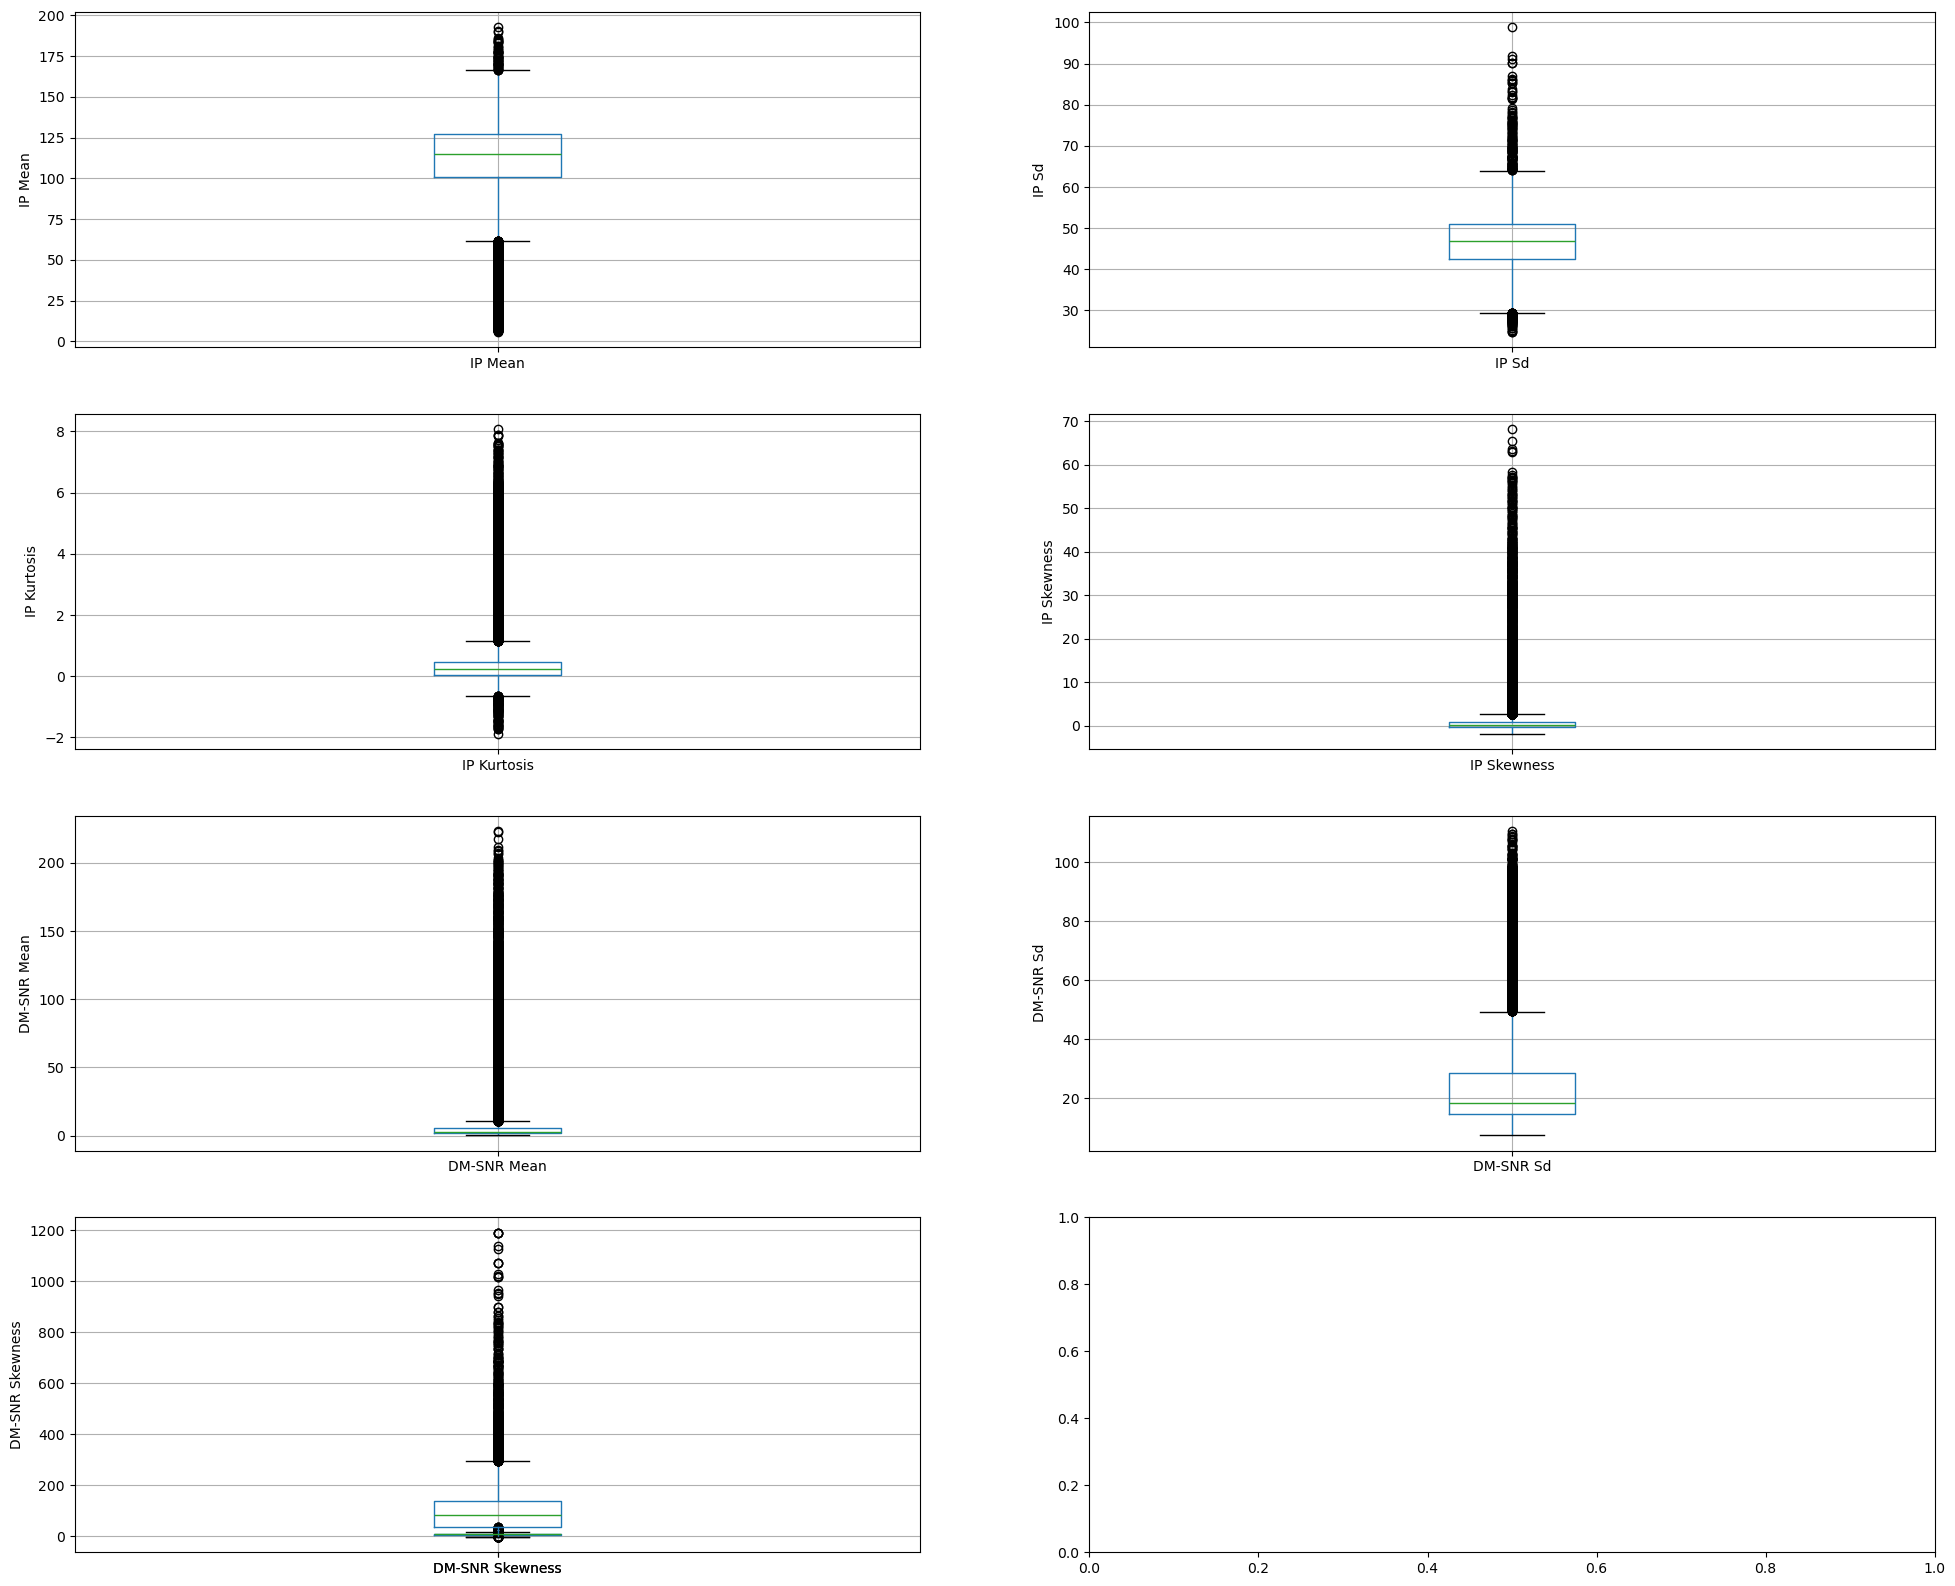

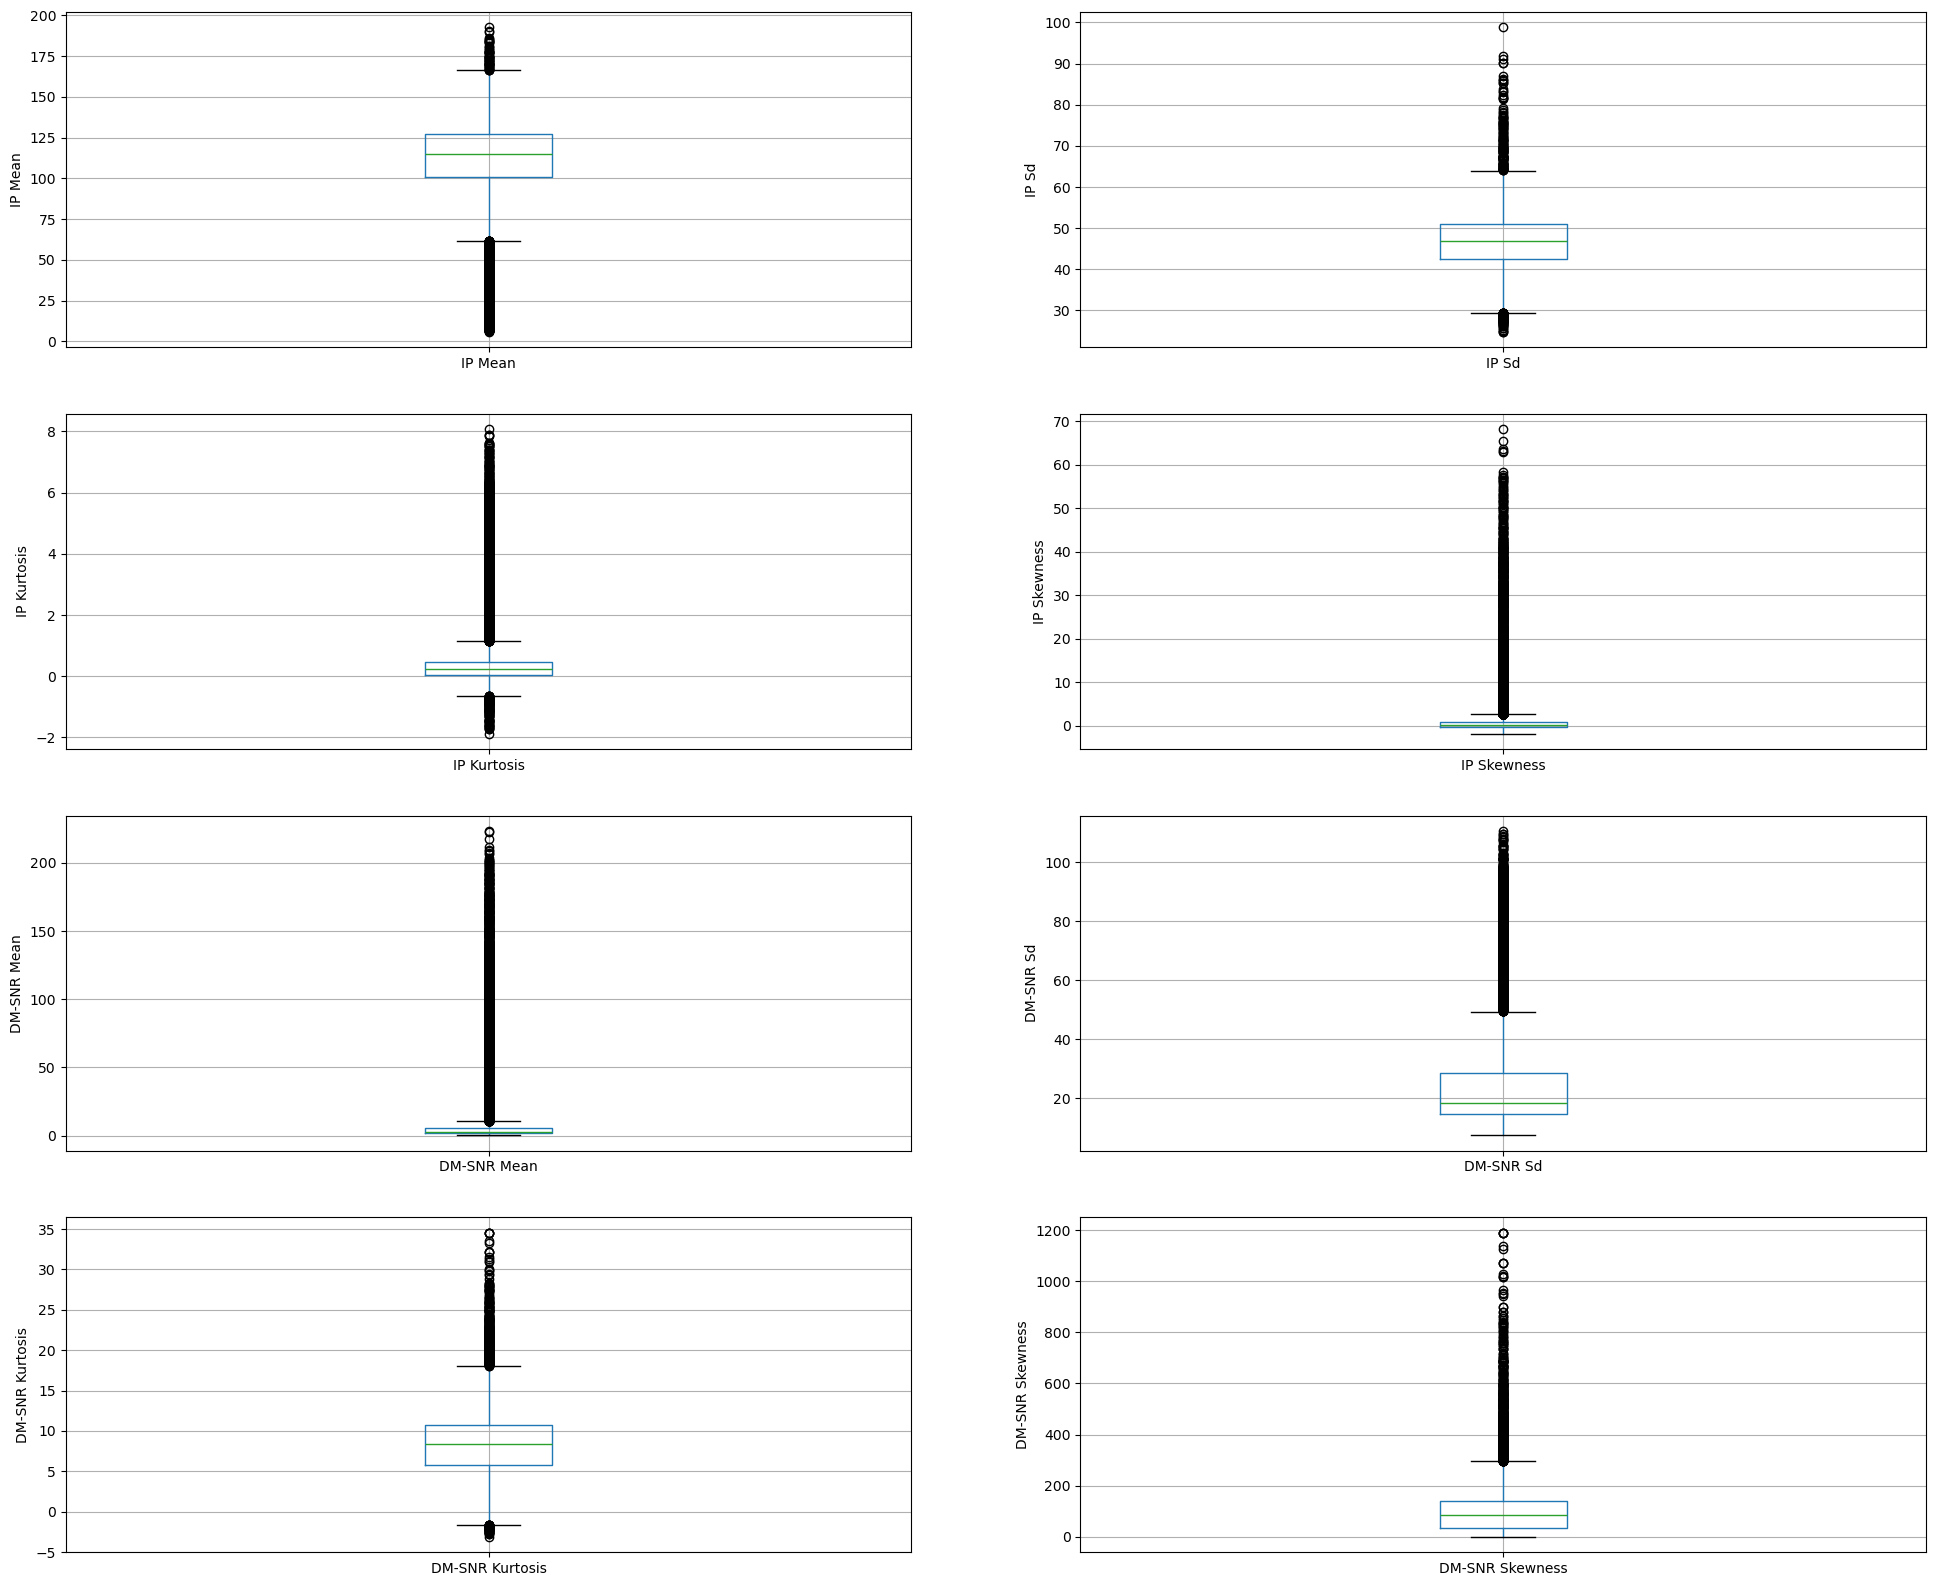

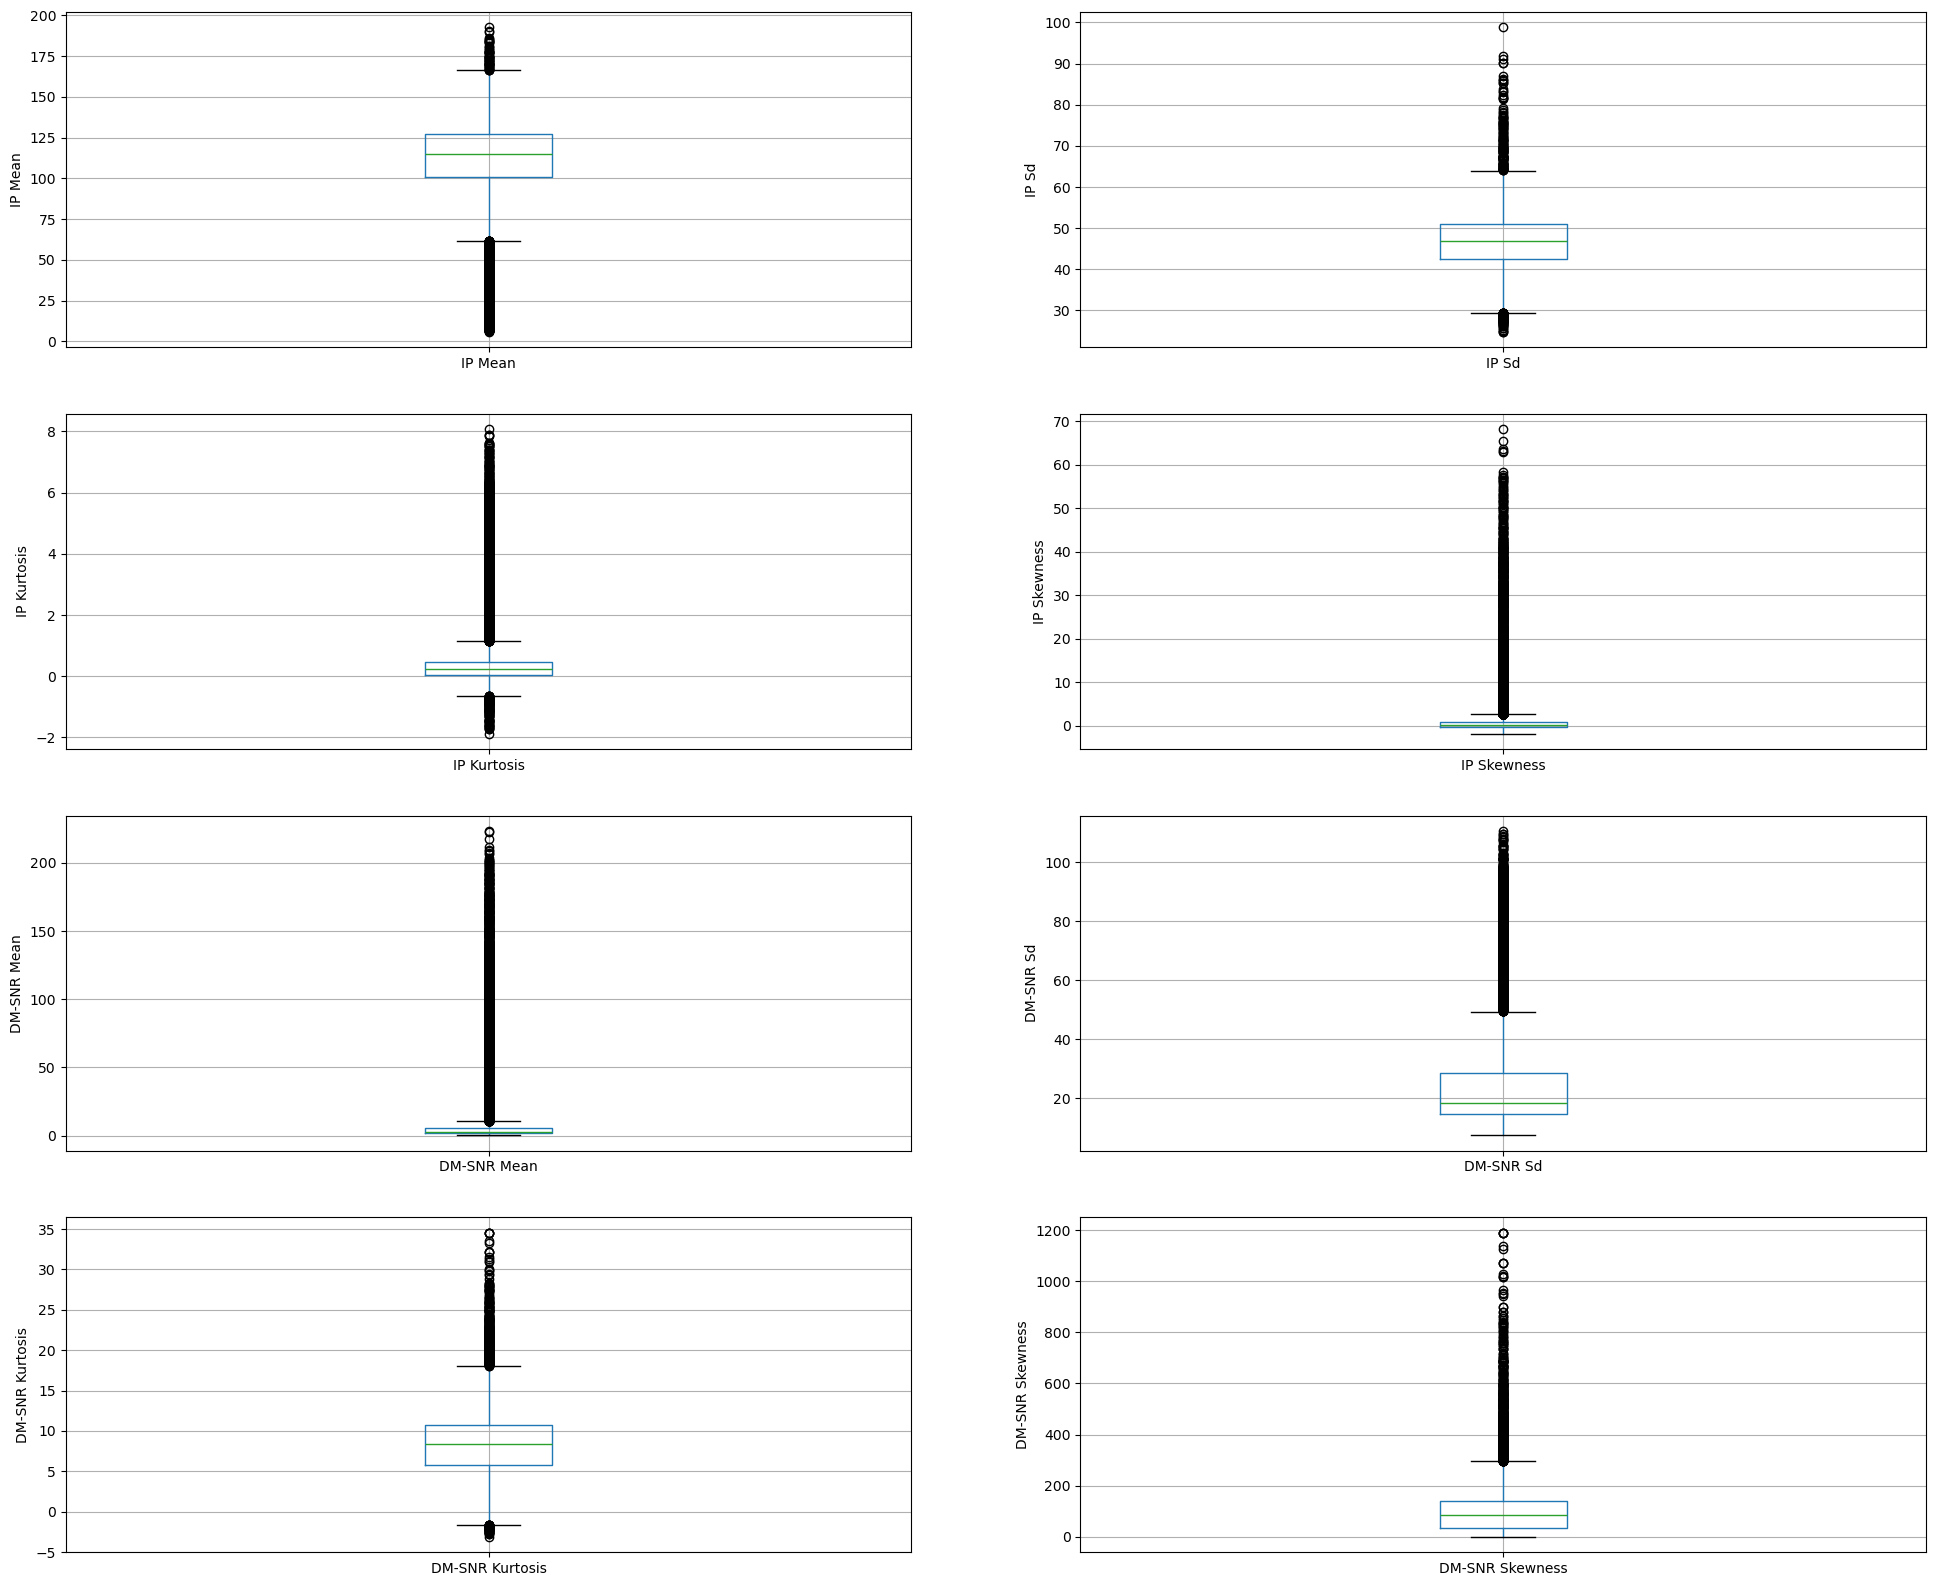

In [80]:
plt.figure(figsize=(24,20))

plt.subplot(4,2,1)
fig=df.boxplot(column='IP Mean')
fig.set_title('')
fig.set_ylabel('IP Mean')

plt.subplot(4,2,2)
fig=df.boxplot(column='IP Sd')
fig.set_title('')
fig.set_ylabel('IP Sd')

plt.subplot(4,2,3)
fig = df.boxplot('IP Kurtosis')
fig.set_title('')
fig.set_ylabel('IP Kurtosis')

plt.subplot(4,2,4)
fig=df.boxplot(column='IP Skewness')
fig.set_title('')
fig.set_ylabel('IP Skewness')

plt.subplot(4,2,5)
fig=df.boxplot(column='DM-SNR Mean')
fig.set_title('')
fig.set_ylabel('DM-SNR Mean')

plt.subplot(4,2,6)
fig=df.boxplot(column='DM-SNR Sd')
fig.set_title('')
fig.set_ylabel('DM-SNR Sd')

plt.subplot(4,2,7)
fig=df.boxplot(column='DM-SNR Kurtosis')
fig.set_title('')
fig.set_ylabel('DM-SNR Kurtosis')

plt.subplot(4,2,8)
fig= df.boxplot(column='DM-SNR Skewness')
fig.set_title('')
fig.set_ylabel('DM-SNR Skewness')

plt.show()

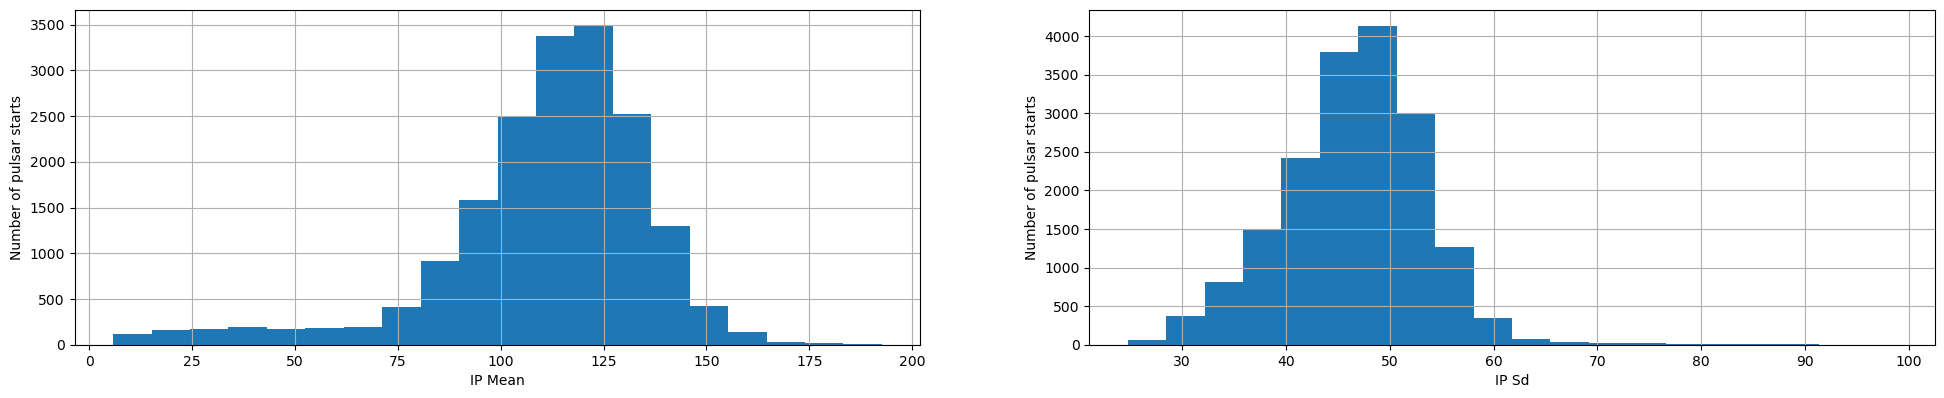

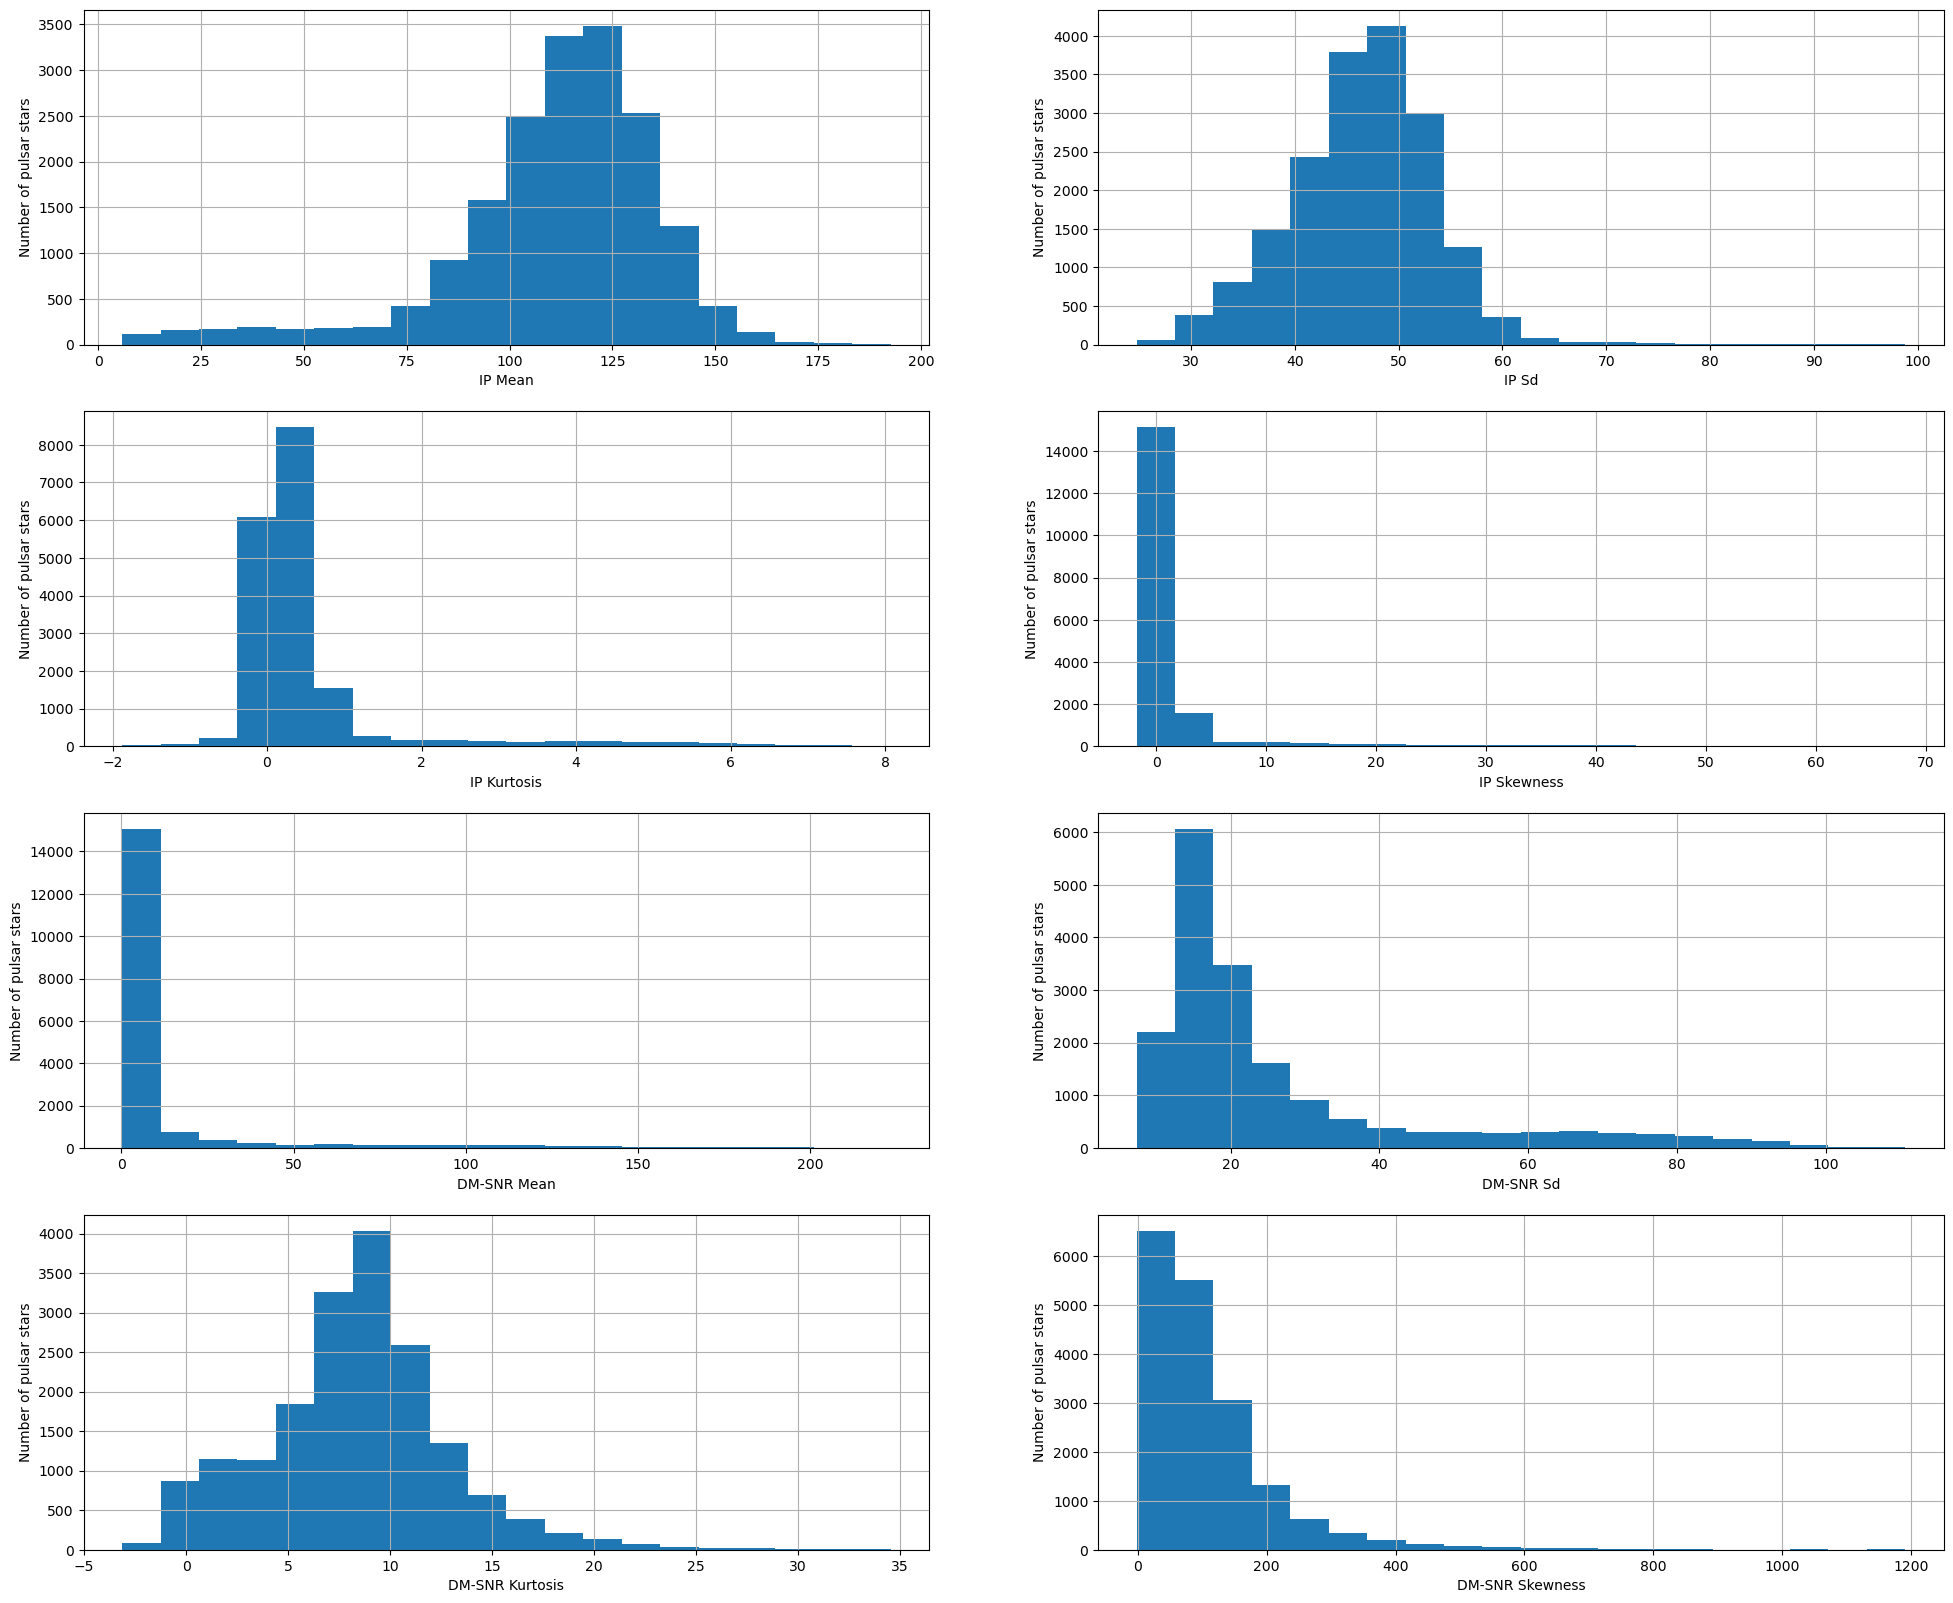

In [90]:
# plot histogram to check distribution


plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df['IP Mean'].hist(bins=20)
fig.set_xlabel('IP Mean')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 2)
fig = df['IP Sd'].hist(bins=20)
fig.set_xlabel('IP Sd')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 3)
fig = df['IP Kurtosis'].hist(bins=20)
fig.set_xlabel('IP Kurtosis')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 4)
fig = df['IP Skewness'].hist(bins=20)
fig.set_xlabel('IP Skewness')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 5)
fig = df['DM-SNR Mean'].hist(bins=20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 6)
fig = df['DM-SNR Sd'].hist(bins=20)
fig.set_xlabel('DM-SNR Sd')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 7)
fig = df['DM-SNR Kurtosis'].hist(bins=20)
fig.set_xlabel('DM-SNR Kurtosis')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 8)
fig = df['DM-SNR Skewness'].hist(bins=20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')


plt.show()

In [92]:
x = df.drop(['target_class'],axis=1)
y = df['target_class']


In [98]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [100]:
x_train.shape,x_test.shape

((14318, 8), (3580, 8))

In [102]:
cols=x_train.columns

In [104]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [108]:
X_train = pd.DataFrame(x_train,columns=[cols])
X_test = pd.DataFrame(x_test,columns=[cols])

In [110]:
X_train.describe()

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness
count,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04
mean,1.908113e-16,-6.550610e-16,1.042143e-17,3.870815e-17,-8.734147e-17,-1.617802e-16,-1.513588e-17,1.122785e-16
std,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00
min,-4.035499e+00,-3.181033e+00,-2.185946e+00,-5.744051e-01,-4.239001e-01,-9.733707e-01,-2.455649e+00,-1.003411e+00
25%,-3.896291e-01,-6.069473e-01,-4.256221e-01,-3.188054e-01,-3.664918e-01,-6.125457e-01,-5.641035e-01,-6.627590e-01
50%,1.587461e-01,5.846646e-02,-2.453172e-01,-2.578142e-01,-3.372294e-01,-4.067482e-01,3.170446e-02,-2.059136e-01
75%,6.267059e-01,6.501017e-01,-1.001238e-02,-1.419621e-01,-2.463724e-01,1.078934e-01,5.362759e-01,3.256217e-01
max,3.151882e+00,7.621116e+00,7.008906e+00,1.054430e+01,7.025568e+00,4.292181e+00,5.818557e+00,1.024613e+01


In [114]:
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score
svc= SVC()
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Model Accuracy score with default hyper parameters is {0:0.4f}'.format(accuracy_score(y_test,y_pred)))


Model Accuracy score with default hyper parameters is 0.9830


In [116]:
svc = SVC(C=100.0)
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Model Accuracy score with rbf kernel and C=100: {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model Accuracy score with rbf kernel and C=100: 0.9846


In [118]:
svc = SVC(C=1000)
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Model Accuracy with rbf kernel and C=1000  is {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model Accuracy with rbf kernel and C=1000  is 0.9816


In [120]:
linear_svc = SVC(kernel='linear',C=1.0)
linear_svc.fit(X_train,y_train)
y_pred = linear_svc.predict(X_test)
print('Accuracy with linear Kernel and C=1.0 is {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Accuracy with linear Kernel and C=1.0 is 0.9849


In [126]:
linear_svc100 = SVC(kernel = 'linear',C=100.0)
linear_svc100.fit(X_train,y_train)
y_pred= linear_svc100.predict(X_test)
print('Model Accuracy score with linear Kernel and C=100.0 : {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model Accuracy score with linear Kernel and C=100.0 : 0.9844


In [130]:
lin_svc1000 = SVC(kernel = 'linear',C=1000.0)
lin_svc1000.fit(X_train,y_train)
y_pred = lin_svc1000.predict(X_test)
print('Model Accuracy score with linear KErnel anc C=1000.0 is {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model Accuracy score with linear KErnel anc C=1000.0 is 0.9844


In [134]:
y_pred_train = linear_svc.predict(X_train)
print('Model accuracy with trainig set is {0:0.4f}'.format(accuracy_score(y_train,y_pred_train)))

Model accuracy with trainig set is 0.9783


In [136]:
print('Training set score :{:.4f}'.format(linear_svc.score(X_train,y_train)))
print('Testing set score :{:.4f}'.format(linear_svc.score(X_test,y_test)))

Training set score :0.9783
Testing set score :0.9849


In [138]:
y_test.value_counts()

target_class
0    3306
1     274
Name: count, dtype: int64

In [145]:
null_accuracy = (3306/(3306+274))
print('Null accuracy score : {0:0.4f}'.format(null_accuracy))

Null accuracy score : 0.9235


In [153]:
poly_svc = SVC(kernel = 'poly',C=1.0)
poly_svc.fit(X_train,y_train)
y_pred=poly_svc.predict(X_test)
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'.format(accuracy_score(y_test,y_pred)))


Model accuracy score with polynomial kernel and C=1.0 : 0.9827


In [155]:
poly_svc100=SVC(kernel='poly',C=100.0)
poly_svc100.fit(X_train,y_train)
y_pred = poly_svc100.predict(X_test)
print('Model Accuracy score with polynomial kernel and C=100.0 is {0:0.4f}'.format(accuracy_score(y_test,y_pred)))


Model Accuracy score with polynomial kernel and C=100.0 is 0.9832


In [157]:
sigmoid_svc = SVC(kernel= 'sigmoid',C=1.0)
sigmoid_svc.fit(X_train,y_train)
y_pred = sigmoid_svc.predict(X_test)
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model accuracy score with sigmoid kernel and C=1.0 : 0.8668


In [161]:
sigmoid_svc100 = SVC(kernel='sigmoid',C=100.0)
sigmoid_svc100.fit(X_train,y_train)
y_pred=sigmoid_svc100.predict(x_test)
print('Model accuracy with sigmoid kernel and C=100.0 is {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model accuracy with sigmoid kernel and C=100.0 is 0.8656


In [163]:
y_test.value_counts()

target_class
0    3306
1     274
Name: count, dtype: int64

In [177]:

y_pred_test=linear_svc.predict(X_test)

from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test,y_pred_test)
print('Confusion Matrix : \n\n',cm)
print('True Positve(TP) :',cm[0,0])
print('True Negative(TN) :',cm[1,1])
print('False Positive(FP): ',cm[0,1])
print('False Negative(FN):',cm[1,0])

Confusion Matrix : 

 [[3289   17]
 [  37  237]]
True Positve(TP) : 3289
True Negative(TN) : 237
False Positive(FP):  17
False Negative(FN): 37


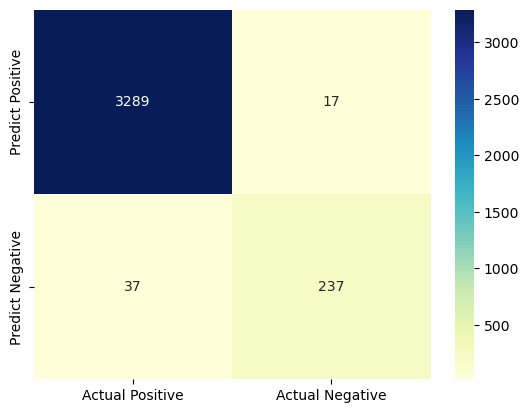

In [198]:
cm_matrix =pd.DataFrame(data=cm,columns=['Actual Positive','Actual Negative'] , index =['Predict Positive','Predict Negative'])
sns.heatmap(cm_matrix,annot=True,fmt='d',cmap='YlGnBu')
plt.show()

In [222]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

predicted_yes =(TP+FP)
actual_yes = (TP+FN)
precision = TP/float(predicted_yes)
recall = TP/float(actual_yes)
accuracy = (TP+TN)/float(TP+TN+FP+FN)
error =(FP+FN)/float(TP+TN+FP+FN)
print('Predicted yes = {0:0.4f} '.format(predicted_yes))
print('Actual yes = {0:0.4f} '.format(actual_yes))
print('accuracy = {0:0.4f} '.format(accuracy))
print('error = {0:0.4f} '.format(error))
print('Precision= {0:0.4f} '.format(precision))

Predicted yes = 3306.0000 
Actual yes = 3326.0000 
accuracy = 0.9849 
error = 0.0151 
Precision= 0.9949 


In [218]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93      3306
           1       0.23      0.31      0.26       274

    accuracy                           0.87      3580
   macro avg       0.58      0.61      0.59      3580
weighted avg       0.89      0.87      0.88      3580

